In [ ]:
import jax.numpy as jnp
import jax
import jaxdem as jd
jax.config.update("jax_enable_x64", True)
import numpy as np
import os
from file_management import make_data_dir, save_arrs

from bump_utils import create_dps_2d, reorder_state, get_com_pos, msd_for_lags, compute_msd
from jaxdem.utils.dynamicsRoutines import control_nvt_density
import matplotlib.pyplot as plt

W0201 10:36:49.191420 2104826 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0201 10:36:49.193291 2104685 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


In [ ]:
which = '2d-soft'
T = 1e-5

if which == '2d-soft':
    from config import config2d_soft as cfg
elif which == '2d-med':
    from config import config2d_med as cfg
elif which == '2d-hard':
    from config import config2d_hard as cfg
else:
    raise ValueError(f'Which {which} is unknown')

seed = np.random.randint(0, 1e9)

state, system, dp = create_dps_2d(
    phi=0.7,
    N=cfg.N,
    mu_eff=cfg.mu_eff,
    aspect_ratio=1.0,
    min_nv=cfg.nv,
    mass=cfg.mass,
    eb=cfg.eb,
    el=cfg.el,
    ec=cfg.ec
)
# state = jd.utils.thermal.set_temperature(state, cfg.target_temperature, can_rotate=False, subtract_drift=True, seed=seed)
key = jax.random.PRNGKey(seed)
dp_vels = jax.random.normal(key, (cfg.N, state.dim))
dp_vels -= jnp.mean(dp_vels, axis=0, keepdims=True)
ke = 0.5 * jnp.sum(dp_vels ** 2) * cfg.mass
temp = ke * 2 / (state.dim * state.N)
# dp_vels *= jnp.sqrt(cfg.target_temperature / temp)
dp_vels *= jnp.sqrt(T / temp)
state.vel = dp_vels[state.deformable_ID]

# run thermalization without compressing the states
print('Running NVT...')
# state, system, (traj_state, traj_system) = jd.utils.control_nvt_density_rollout(
state, system = jd.utils.control_nvt_density(
    state,
    system,
    n=cfg.n_dynamics_steps // 10,
    # stride=100,
    rescale_every=100,
    # temperature_delta=cfg.target_temperature,  # maintain temperature
    temperature_delta=T,  # maintain temperature
    packing_fraction_delta=0.0,  # do not compress on the first run
    can_rotate=False,
    subtract_drift=True,
)
print('Done')

# run dynamics
print('Running dynamics...')
save_stride = 1000
n_dynamics_steps = 1_000_000
n_snapshots = n_dynamics_steps // save_stride
state, system, (state_traj, system_traj) = system.trajectory_rollout(
    state, system, n=n_snapshots, stride=save_stride
)
pe = jax.vmap(jd.utils.thermal.compute_potential_energy)(state_traj, system_traj)
ke = jax.vmap(jd.utils.compute_translational_kinetic_energy)(state_traj)
state_traj = jax.vmap(reorder_state)(state_traj)

Running NVT...
Done
Running dynamics...


In [36]:
# run thermalization without compressing the states
print('Running NVT...')
# state, system, (traj_state, traj_system) = jd.utils.control_nvt_density_rollout(
state, system = jd.utils.control_nvt_density(
    state,
    system,
    n=100_000,
    # stride=100,
    rescale_every=100,
    # temperature_delta=cfg.target_temperature,  # maintain temperature
    temperature_delta=T,  # maintain temperature
    packing_fraction_delta=0.0,  # do not compress on the first run
    can_rotate=False,
    subtract_drift=True,
)
print('Done')

# run dynamics
print('Running dynamics...')
save_stride = 1000
n_dynamics_steps = 1_000_000
n_snapshots = n_dynamics_steps // save_stride
state, system, (state_traj, system_traj) = system.trajectory_rollout(
    state, system, n=n_snapshots, stride=save_stride
)
pe = jax.vmap(jd.utils.thermal.compute_potential_energy)(state_traj, system_traj)
ke = jax.vmap(jd.utils.compute_translational_kinetic_energy)(state_traj)
state_traj = jax.vmap(reorder_state)(state_traj)

Running NVT...
Done
Running dynamics...


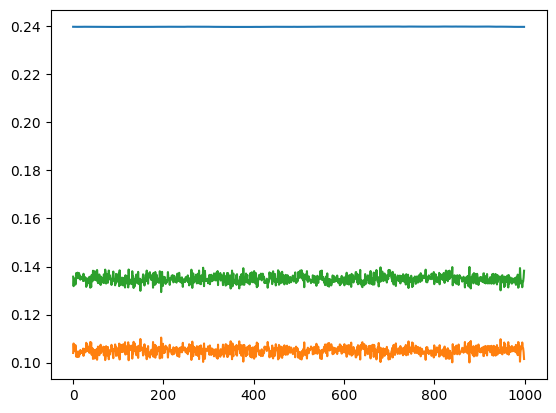

In [37]:
plt.plot(pe + ke)
plt.plot(pe)
plt.plot(ke)

In [44]:
from bump_utils import animate
animate(state_traj, system_traj, 'anim.gif')

Preprocess: 100%|██████████| 100/100 [00:00<00:00, 437.42it/s]


Saved GIF to anim.gif


In [41]:
N_dps = int(jax.device_get(jnp.max(state_traj.deformable_ID))) + 1
pos_dp = jax.vmap(lambda st: get_com_pos(st, N_dps=N_dps))(state_traj)

In [42]:
from tqdm import tqdm

@jax.jit
def msd_for_lags(dp_com: jax.Array, lags: jax.Array) -> jax.Array:
    T = dp_com.shape[0]
    M = dp_com.shape[1]
    t = jnp.arange(T, dtype=lags.dtype)  # (T,)

    def msd_one(lag: jax.Array) -> jax.Array:
        # y[t] = dp_com[t + lag] (mod T) with a validity mask to drop wrapped terms
        idx = (t + lag) % T  # (T,)
        diff = dp_com[idx] - dp_com  # (T, M, dim)
        sq = jnp.sum(diff * diff, axis=-1)  # (T, M)

        valid = (t < (T - lag)).astype(dp_com.dtype)  # (T,)
        numer = jnp.sum(sq * valid[:, None])
        denom = (T - lag) * M
        return numer / denom

    return jax.vmap(msd_one)(lags)

def compute_msd(pos):
    # Compute MSD with a JIT-compiled kernel. To avoid doing "all at once", run lags in batches.
    t = np.arange(1, pos.shape[0] - 1, dtype=np.int32)
    msd = np.empty((t.size,), dtype=np.float64)

    batch = 256  # increase for more throughput, decrease for lower peak memory
    for s in tqdm(range(0, t.size, batch)):
        lags = jnp.asarray(t[s : s + batch])
        msd[s : s + batch] = np.asarray(msd_for_lags(pos, lags))
    return msd, t

100%|██████████| 4/4 [00:00<00:00, 341.10it/s]


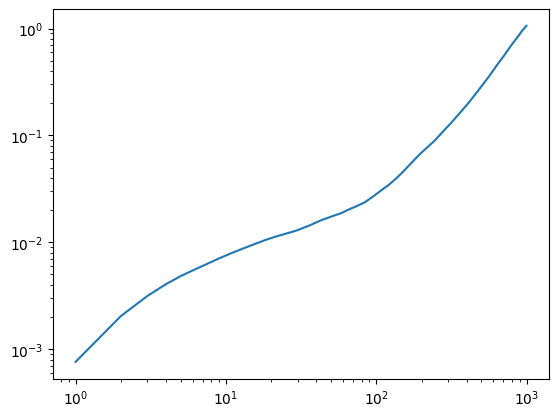

In [45]:
msd, t = compute_msd(pos_dp)

plt.plot(t, msd)
plt.xscale('log')
plt.yscale('log')